<a href="https://colab.research.google.com/github/wanchenlang-max/econ5200-lab/blob/lab8/lab8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [5]:
from google.colab import files
uploaded = files.upload()


Saving lalonde.xlsx to lalonde (1).xlsx


In [6]:
import pandas as pd

df = pd.read_excel('lalonde.xlsx')


In [7]:
df.head()


,Unnamed: 0,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78
0,1,1,37,11,1,0,1,1,0.0,0.0,9930.0460
1,2,1,22,9,0,1,0,1,0.0,0.0,3595.8940
2,3,1,30,12,1,0,0,0,0.0,0.0,24909.4500
3,4,1,27,11,1,0,0,1,0.0,0.0,7506.1460
4,5,1,33,8,1,0,0,1,0.0,0.0,289.7899


In [19]:
treat = df[df['treat'] == 1]['re78']
control = df[df['treat'] == 0]['re78']

print(f"Mean Treated: ${treat.mean():.2f}")
print(f"Mean Control: ${control.mean():.2f}")


Mean Treated: $6349.14
Mean Control: $6984.17


In [20]:
df = pd.read_excel('lalonde.xlsx')


In [18]:
# 1. Load Data (Lalonde Experimental Subset)
df = pd.read_excel('lalonde.xlsx')

# 2. Split Groups
treat = df[df['treat'] == 1]['re78']
control = df[df['treat'] == 0]['re78']

# Inspect the raw means (The "Economic Reality")
print(f"Mean Treated: ${treat.mean():.2f}")
print(f"Mean Control: ${control.mean():.2f}")

Mean Treated: $6349.14
Mean Control: $6984.17


In [21]:
# 3. Calculate Signal (Difference in Means)
signal = treat.mean() - control.mean()

# 4. Calculate Noise (T-Test)
t_stat, p_val = stats.ttest_ind(treat, control, equal_var=False)

print(f"Treatment Effect (Signal): ${signal:.2f}")
print(f"T-Statistic (Signal/Noise): {t_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

# Decision Rule (Alpha = 0.05)
if p_val < 0.05:
    print("Reject Null: The training has a statistically significant effect.")
else:
    print("Fail to Reject Null: Result could be due to chance.")

Treatment Effect (Signal): $-635.03
T-Statistic (Signal/Noise): -0.9377
P-Value: 0.3491
Fail to Reject Null: Result could be due to chance.


In [22]:
# Define the test statistic function
def difference_in_means(x, y):
    return np.mean(x) - np.mean(y)


# Run Permutation Test (10,000 Resamples)
# This simulates "What if the treatment labels were meaningless?"
res = stats.permutation_test((treat, control), difference_in_means,
                             permutation_type='independent',
                             n_resamples=10000,
                             alternative='two-sided')

print(f"Permutation P-Value: {res.pvalue:.4f}")
print("compare this to your T-test P-value. Are they consistent?")

Permutation P-Value: 0.3246
compare this to your T-test P-value. Are they consistent?


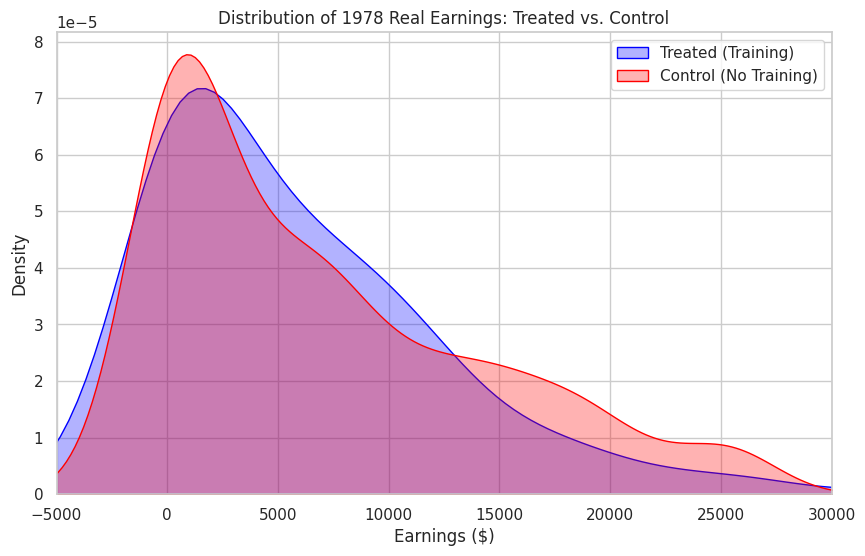

In [23]:
plt.figure(figsize=(10, 6))

# Plot KDE (Kernel Density Estimate) for both groups
sns.kdeplot(treat, fill=True, label='Treated (Training)', color='blue', alpha=0.3)
sns.kdeplot(control, fill=True, label='Control (No Training)', color='red', alpha=0.3)

plt.title('Distribution of 1978 Real Earnings: Treated vs. Control')
plt.xlabel('Earnings ($)')
plt.xlim(-5000, 30000) # Limit x-axis to focus on the core distribution
plt.legend()
plt.show()

In [ ]:
import s